# ch209 — Gradient Intuition

**Part VII: Calculus**

---

## 1. From Derivative to Gradient

The derivative f'(x) *(ch205)* tells you the rate of change of a scalar function of one variable. When the function takes a vector as input, the analog is the **gradient**.

For f: ℝⁿ → ℝ (scalar output), the gradient is the vector of all partial derivatives:

$$\nabla f(\mathbf{x}) = \begin{bmatrix} \partial f/\partial x_1 \\ \partial f/\partial x_2 \\ \vdots \\ \partial f/\partial x_n \end{bmatrix}$$

The gradient is a **vector** *(Part V — Vectors)* pointing in the direction of steepest ascent.

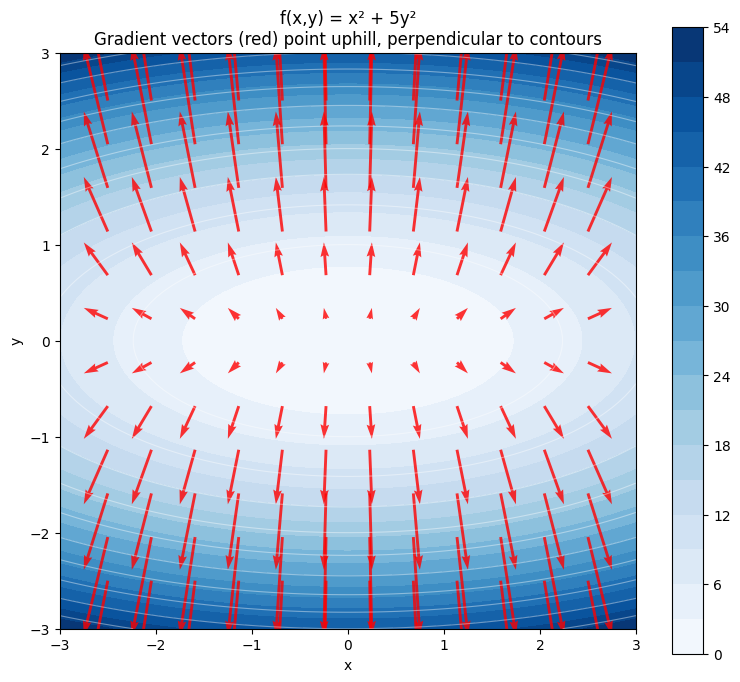

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# f(x, y) = x^2 + 5y^2, gradient = [2x, 10y]
f   = lambda x, y: x**2 + 5*y**2
gf  = lambda x, y: np.array([2*x, 10*y])

x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
Z    = f(X, Y)

xg = np.linspace(-2.5, 2.5, 12)
yg = np.linspace(-2.5, 2.5, 12)
Xg, Yg = np.meshgrid(xg, yg)
Ug = 2*Xg
Vg = 10*Yg

fig, ax = plt.subplots(figsize=(8, 7))
cs = ax.contourf(X, Y, Z, levels=20, cmap='Blues')
ax.contour(X, Y, Z, levels=10, colors='white', alpha=0.4, linewidths=0.8)
plt.colorbar(cs, ax=ax)
ax.quiver(Xg, Yg, Ug, Vg, color='red', alpha=0.8, scale=120)
ax.set_title('f(x,y) = x² + 5y²\nGradient vectors (red) point uphill, perpendicular to contours')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 2. Directional Derivative

The rate of change of f in direction **u** (unit vector):

$$D_{\mathbf{u}} f(\mathbf{x}) = \nabla f(\mathbf{x}) \cdot \mathbf{u}$$

This is a dot product *(ch131 — Dot Product Intuition)*. Maximum when **u** aligns with the gradient; zero when perpendicular.

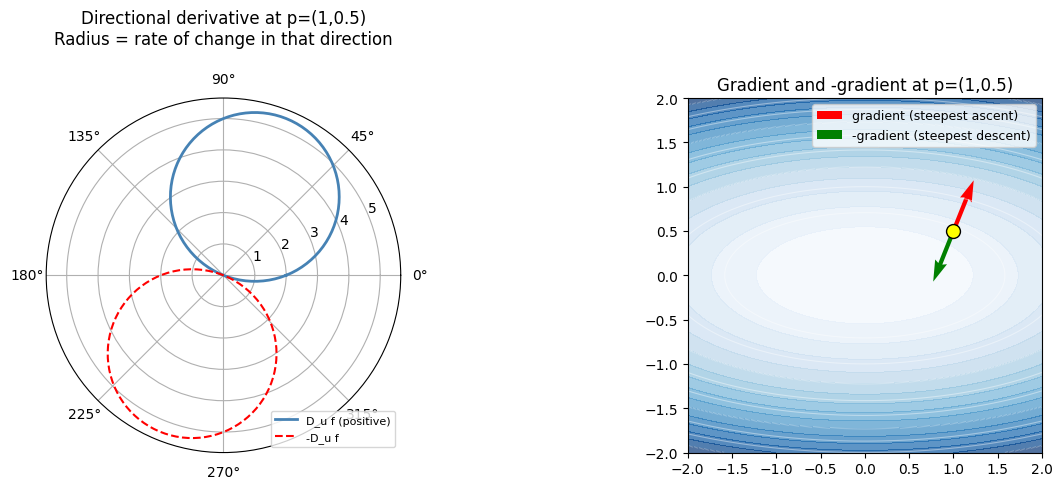

Gradient at p=[1.  0.5]: [2. 5.]
Magnitude (max rate of change): 5.3852


In [2]:
p = np.array([1.0, 0.5])
g = np.array([2*p[0], 10*p[1]])

thetas = np.linspace(0, 2*np.pi, 360)
dirs   = np.column_stack([np.cos(thetas), np.sin(thetas)])
dir_derivs = dirs @ g

fig = plt.figure(figsize=(13, 5))

ax1 = fig.add_subplot(121, projection='polar')
ax1.plot(thetas, np.maximum(dir_derivs, 0), color='steelblue', linewidth=2, label='D_u f (positive)')
ax1.plot(thetas, np.maximum(-dir_derivs, 0), color='red', linewidth=1.5, linestyle='--', label='-D_u f')
ax1.set_title('Directional derivative at p=(1,0.5)\nRadius = rate of change in that direction', pad=20)
ax1.legend(loc='lower right', fontsize=8)

ax2 = fig.add_subplot(122)
X2, Y2 = np.meshgrid(np.linspace(-2, 2, 80), np.linspace(-2, 2, 80))
ax2.contourf(X2, Y2, f(X2, Y2), levels=15, cmap='Blues', alpha=0.7)
ax2.contour(X2, Y2, f(X2, Y2), levels=10, colors='white', alpha=0.4, linewidths=0.8)
ax2.quiver(*p, g[0], g[1], color='red', scale=35, width=0.012, label='gradient (steepest ascent)')
ax2.quiver(*p, -g[0], -g[1], color='green', scale=35, width=0.012, label='-gradient (steepest descent)')
ax2.scatter(*p, color='yellow', zorder=8, s=100, edgecolors='black')
ax2.set_title('Gradient and -gradient at p=(1,0.5)')
ax2.legend(fontsize=9)
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

print(f'Gradient at p={p}: {g}')
print(f'Magnitude (max rate of change): {np.linalg.norm(g):.4f}')

## 3. Gradient of a Loss Function

In [3]:
np.random.seed(0)
N, D = 50, 4
X_data = np.random.randn(N, D)
w_true = np.array([2.0, -1.0, 0.5, -0.3])
y_data = X_data @ w_true + 0.1 * np.random.randn(N)

def mse_loss(w):
    return np.mean((X_data @ w - y_data)**2)

def mse_gradient(w):
    residuals = X_data @ w - y_data
    return (2/N) * X_data.T @ residuals

w_init = np.zeros(D)
grad = mse_gradient(w_init)

print(f'MSE gradient of linear regression at w=0:')
print(f'  Loss:     {mse_loss(w_init):.6f}')
print(f'  Gradient: {np.round(grad, 4)}')
print()
print('Interpretation: increasing w[i] by epsilon changes loss by ~gradient[i]*epsilon')
for i, g_i in enumerate(grad):
    direction = 'increases' if g_i > 0 else 'decreases'
    print(f'  w[{i}]: {direction} loss by ~{abs(g_i):.4f} per unit increase')

MSE gradient of linear regression at w=0:
  Loss:     7.174992
  Gradient: [-5.7091  2.3249 -1.0152  0.0173]

Interpretation: increasing w[i] by epsilon changes loss by ~gradient[i]*epsilon
  w[0]: decreases loss by ~5.7091 per unit increase
  w[1]: increases loss by ~2.3249 per unit increase
  w[2]: decreases loss by ~1.0152 per unit increase
  w[3]: increases loss by ~0.0173 per unit increase


## 4. Summary

- Gradient ∇f(x): vector of all partial derivatives, same dimension as x
- Points toward steepest increase; -gradient points toward steepest decrease
- Directional derivative = dot product of gradient with unit direction vector
- Gradient is perpendicular to contour lines at every point
- In ML: gradient of the loss w.r.t. weights tells us how to update weights

---

## 5. Forward References

Partial derivatives — the components of the gradient — are derived in ch210 — Partial Derivatives. The gradient descent algorithm is ch212 — Gradient Descent. The gradient of a vector-to-vector function (the Jacobian matrix) appears in ch215 — Chain Rule and drives ch216 — Backpropagation Intuition.